# Eksperimen Preprocessing - Dataset Wine Quality
Nama Siswa: Reinhart Jens Robert

## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## 2. Data Loading

In [2]:
df = pd.read_csv("../winequality_raw.csv", sep=';')
print("Shape dataset:", df.shape)
df.head()

Shape dataset: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
print("Kolom dataset:", df.columns.tolist())
print("\nTipe data:\n", df.dtypes)

Kolom dataset: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

Tipe data:
 fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object


## 3. Exploratory Data Analysis (EDA)

In [4]:
print("=== INFO DATASET ===")
df.info()

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [5]:
print("=== STATISTIK DESKRIPTIF ===")
df.describe()

=== STATISTIK DESKRIPTIF ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [6]:
print("=== MISSING VALUES ===")
print(df.isnull().sum())

=== MISSING VALUES ===
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


In [7]:
print("=== DUPLIKASI ===")
print(f"Jumlah baris duplikat: {df.duplicated().sum()}")

=== DUPLIKASI ===
Jumlah baris duplikat: 240


In [8]:
print("=== DISTRIBUSI TARGET (quality) ===")
print(df['quality'].value_counts())

=== DISTRIBUSI TARGET (quality) ===
quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64


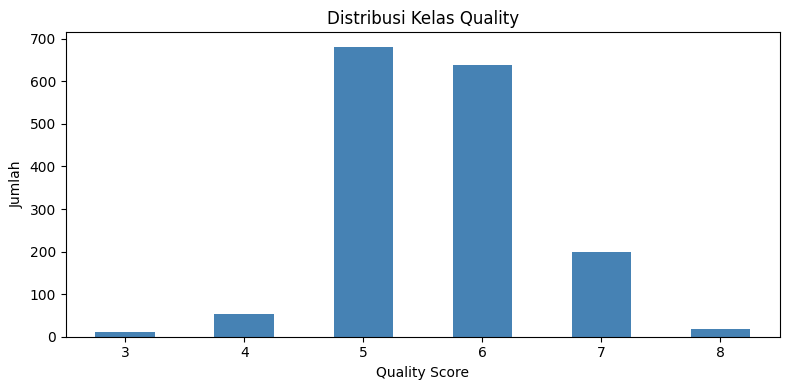

In [9]:
plt.figure(figsize=(8, 4))
df['quality'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Distribusi Kelas Quality')
plt.xlabel('Quality Score')
plt.ylabel('Jumlah')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('eda_class_distribution.png')
plt.show()

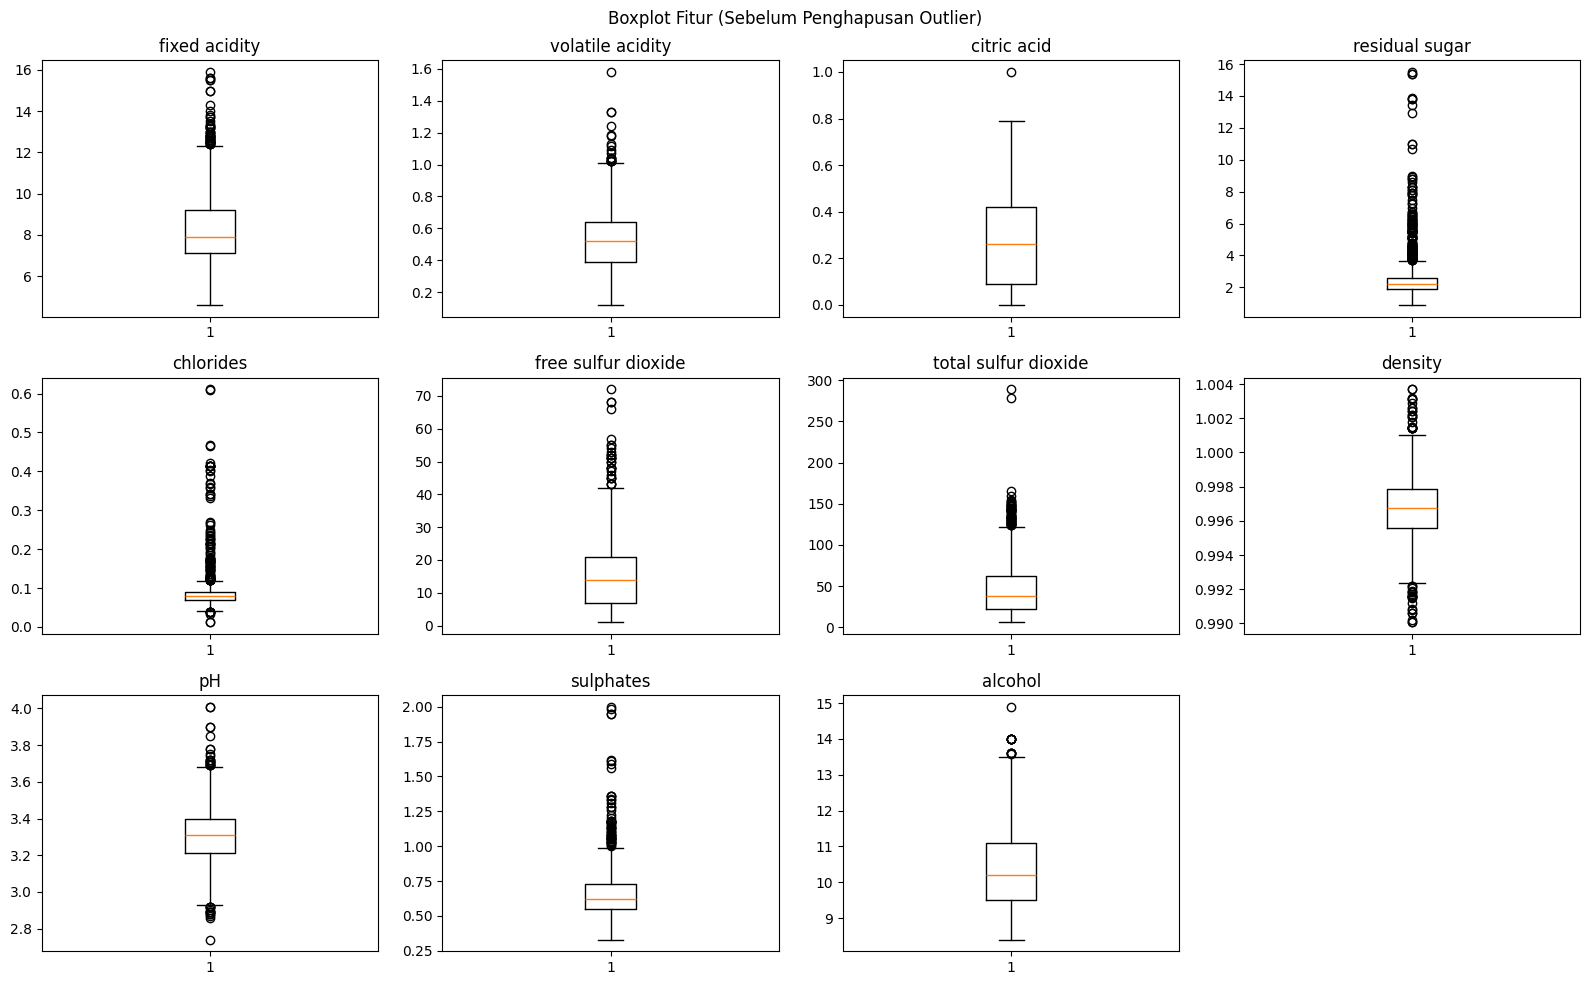

In [10]:
feature_cols = [col for col in df.columns if col != 'quality']
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(feature_cols):
    axes[i].boxplot(df[col])
    axes[i].set_title(col)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
fig.suptitle('Boxplot Fitur (Sebelum Penghapusan Outlier)')
plt.tight_layout()
plt.savefig('eda_boxplot.png')
plt.show()

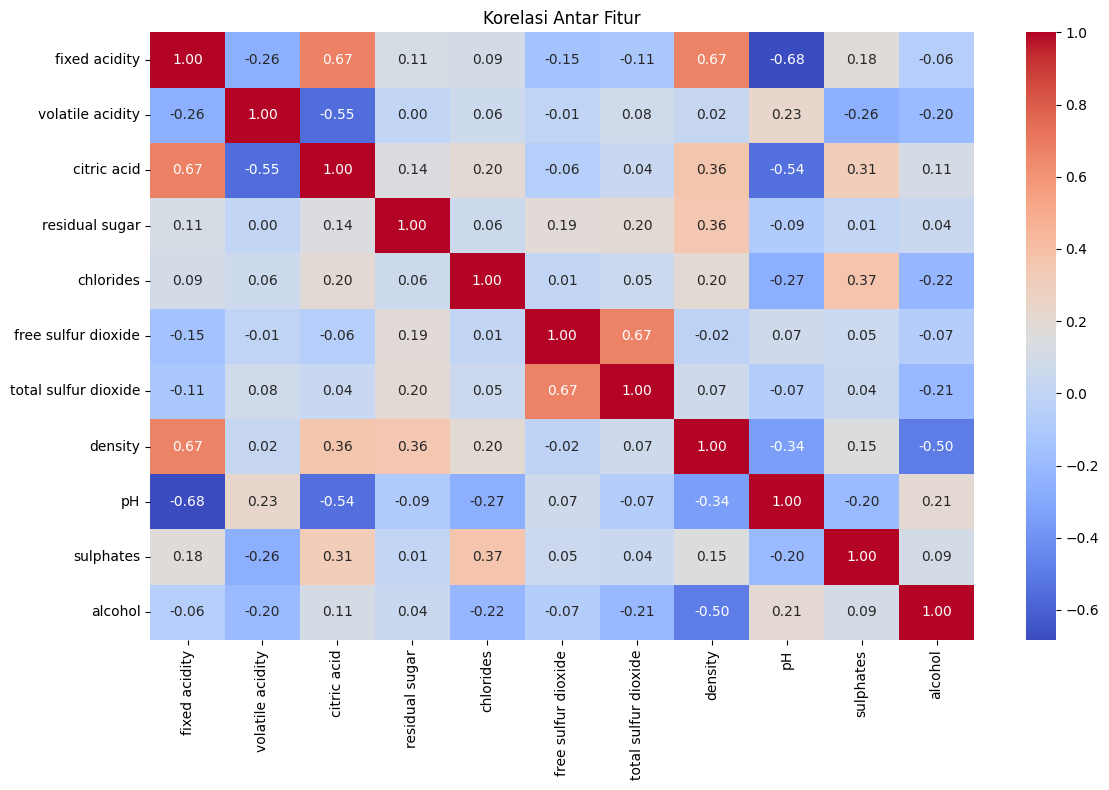

In [11]:
plt.figure(figsize=(12, 8))
sns.heatmap(df[feature_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Korelasi Antar Fitur')
plt.tight_layout()
plt.savefig('eda_correlation.png')
plt.show()

## 4. Preprocessing

### 4.1 Handling Missing Values

In [12]:
missing = df.isnull().sum()
print("Missing values per kolom:")
print(missing)
if missing.sum() == 0:
    print("\nTidak ada missing values.")
else:
    df = df.dropna()
    print(f"\nMissing values dihapus. Shape: {df.shape}")

Missing values per kolom:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Tidak ada missing values.


### 4.2 Handling Duplicates

In [13]:
dup = df.duplicated().sum()
print(f"Jumlah duplikasi: {dup}")
if dup > 0:
    df = df.drop_duplicates()
    print(f"Duplikasi dihapus. Shape: {df.shape}")
else:
    print("Tidak ada duplikasi.")

Jumlah duplikasi: 240
Duplikasi dihapus. Shape: (1359, 12)


### 4.3 Handling Outliers (IQR Method)

In [14]:
print(f"Shape sebelum hapus outlier: {df.shape}")
for col in feature_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower) & (df[col] <= upper)]
print(f"Shape setelah hapus outlier: {df.shape}")

Shape sebelum hapus outlier: (1359, 12)
Shape setelah hapus outlier: (985, 12)


### 4.4 Binarize Target

In [15]:
df['quality'] = (df['quality'] >= 6).astype(int)
print("Target setelah binarisasi:")
print(df['quality'].value_counts())

Target setelah binarisasi:
quality
1    536
0    449
Name: count, dtype: int64


### 4.5 Train-Test Split

In [16]:
X = df[feature_cols]
y = df['quality']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")

X_train: (788, 11)
X_test: (197, 11)


### 4.6 Feature Scaling

In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Feature scaling selesai.")

Feature scaling selesai.


### 4.7 Simpan Hasil Preprocessing

In [18]:
import os
os.makedirs("winequality_preprocessing", exist_ok=True)

train_df = pd.DataFrame(X_train_scaled, columns=feature_cols)
train_df['quality'] = y_train.values
train_df.to_csv("winequality_preprocessing/winequality_train.csv", index=False)

test_df = pd.DataFrame(X_test_scaled, columns=feature_cols)
test_df['quality'] = y_test.values
test_df.to_csv("winequality_preprocessing/winequality_test.csv", index=False)

print("Data preprocessing disimpan ke folder winequality_preprocessing/")
print(f"Train: {train_df.shape}")
print(f"Test:  {test_df.shape}")

Data preprocessing disimpan ke folder winequality_preprocessing/
Train: (788, 12)
Test:  (197, 12)


In [19]:
train_check = pd.read_csv("winequality_preprocessing/winequality_train.csv")
print("\nVerifikasi train dataset:")
print(train_check.head())


Verifikasi train dataset:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0      -0.697902         -1.041502     0.241039        0.719242   1.205781   
1       0.861750         -1.100446     0.681860        0.053246  -0.207340   
2      -1.308200          0.432092    -0.916116       -0.390751   0.802032   
3       0.319262         -0.334177     0.130834        0.275244  -1.553169   
4       0.183640          0.726811     1.949220       -0.168753   2.282445   

   free sulfur dioxide  total sulfur dioxide   density        pH  sulphates  \
0             0.658710              0.474594 -0.203466  0.694338   0.199222   
1            -1.144846             -1.126349  0.932337 -0.829725  -0.069438   
2             2.101555              0.114382 -1.023768  0.922948  -0.427650   
3            -0.062712             -0.525995 -0.859708 -1.134537   1.542519   
4            -0.303187              1.955466  0.490636 -0.982131  -0.964969   

    alcohol  quality  
0  0.6